# Metrics for Joint Simulation

**WARNING: The toy dataset used in this example only contains 17 IDs, which is not sufficient to get satisfactory results. For a more comprehensive evaluation, consider using a larger dataset. The metrics in the Notebook 3 are also more suitable for evaluating the performance of the joint simulation.**

## Initialization and Simulation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp
from lifelines import KaplanMeierFitter
from tqdm import tqdm

from leaspy.io.data import Data
from leaspy.models import JointModel
from leaspy.datasets import load_dataset

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Load data
data = Data.from_dataframe(load_dataset("simulated_data_for_joint"), "joint")
df = data.to_dataframe()

# Load the model directly from the JSON file
model = JointModel.load("../models/model_on_simulated_data_for_joint_100000_iterations.json")

### Parameters given by Optuna study

weights = {3.0, 1.5, 1.0, 1.0}; feat_weights = {1.5, 1.5, 1.0, 2.0}

In [3]:
# visit_params = {
#     "patient_number": 50,
#     "visit_type": "random",
#     "first_visit_mean": -5.055112362909396,
#     "first_visit_std": 0.13590615779543,
#     "time_follow_up_mean": 12.190678400736429,
#     "time_follow_up_std": 1.675989067382816,
#     "distance_visit_mean": 0.13590615779543,
#     "distance_visit_std": 0.1374382268452965,
#     "min_spacing_between_visits": 0.7513616053051078
# }

### Dynamic estimation of parameters from data (now included in joint_simulate directly if missing value detected)

In [4]:
visit_params = {
    "patient_number": 50,
    "visit_type": "random",
    "data": data
}

In [5]:
from IPython.utils import io

with io.capture_output() as captured:
    M = 100

    sims = []
    for m in tqdm(range(M), desc="Simulations"):
        df_s = model.simulate(
            algorithm="joint_simulate",
            features=model.features,
            visit_parameters=visit_params,
        )
        sims.append(df_s.data.to_dataframe())

    display(sims[0].head())

## The Metrics

### Density and CDF

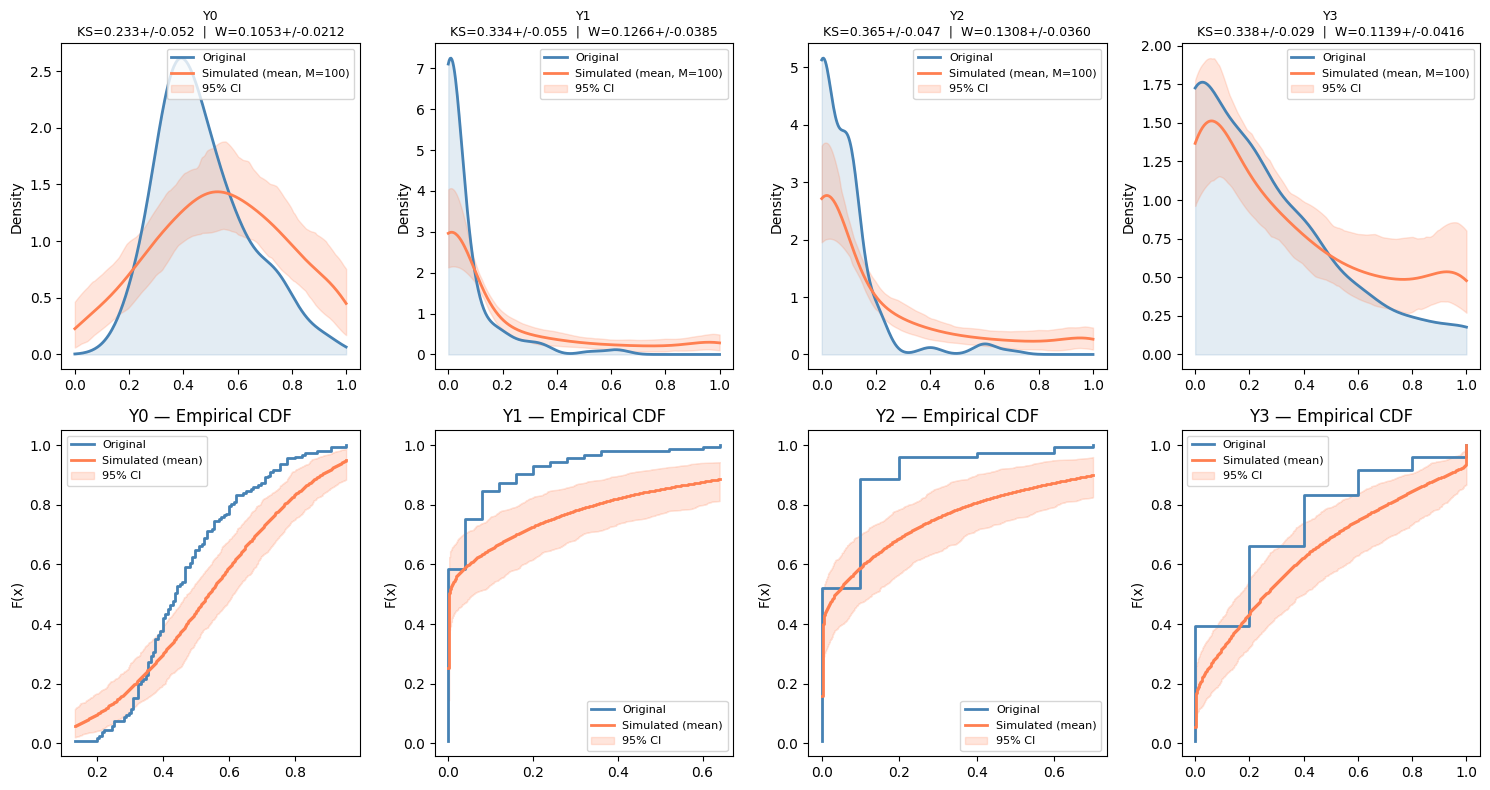

,Feature,KS mean,KS std,Wasserstein mean,Wasserstein std
0,Y0,0.2332,0.0519,0.1053,0.0212
1,Y1,0.3341,0.0550,0.1266,0.0385
2,Y2,0.3645,0.0469,0.1308,0.0360
3,Y3,0.3385,0.0293,0.1139,0.0416


In [6]:
feat_cols = model.features

# Common x-grid (union of original range and all sims ranges)
x_grids = {}
for col in feat_cols:
    lo = min(df[col].min(), *(s[col].min() for s in sims))
    hi = max(df[col].max(), *(s[col].max() for s in sims))
    x_grids[col] = np.linspace(lo, hi, 300)

# Per-simulation KDE values and scalar metrics
kde_sim_all = {col: [] for col in feat_cols}
ks_all      = {col: [] for col in feat_cols}
wass_all    = {col: [] for col in feat_cols}

for df_s in sims:
    for col in feat_cols:
        a = df[col].dropna().values
        b = df_s[col].dropna().values
        kde_sim_all[col].append(stats.gaussian_kde(b)(x_grids[col]))
        ks_all[col].append(ks_2samp(a, b)[0])
        wass_all[col].append(wasserstein_distance(a, b))

fig, axes = plt.subplots(2, len(feat_cols), figsize=(15, 8))
summary_rows = []

for col, ax_kde, ax_cdf in zip(feat_cols, axes[0], axes[1]):
    xs = x_grids[col]
    a  = df[col].dropna().values

    # KDE panel
    kde_orig = stats.gaussian_kde(a)
    ax_kde.plot(xs, kde_orig(xs), label='Original', color='steelblue', lw=2)
    ax_kde.fill_between(xs, kde_orig(xs), alpha=0.15, color='steelblue')

    kde_mat  = np.array(kde_sim_all[col])   # (M, 300)
    kde_mean = kde_mat.mean(axis=0)
    kde_lo   = np.percentile(kde_mat, 2.5, axis=0)
    kde_hi   = np.percentile(kde_mat, 97.5, axis=0)
    ax_kde.plot(xs, kde_mean, label=f'Simulated (mean, M={M})', color='coral', lw=2)
    ax_kde.fill_between(xs, kde_lo, kde_hi, alpha=0.2, color='coral', label='95% CI')

    ks_m,   ks_s   = np.mean(ks_all[col]),   np.std(ks_all[col])
    wass_m, wass_s = np.mean(wass_all[col]), np.std(wass_all[col])
    ax_kde.set_title(f'{col}\nKS={ks_m:.3f}+/-{ks_s:.3f}  |  W={wass_m:.4f}+/-{wass_s:.4f}', fontsize=9)
    ax_kde.legend(fontsize=8)
    ax_kde.set_ylabel('Density')

    # ECDF panel
    x_ecdf   = np.linspace(a.min(), a.max(), 300)
    arr_orig = np.sort(a)
    ys_orig  = np.arange(1, len(arr_orig) + 1) / len(arr_orig)
    ax_cdf.step(arr_orig, ys_orig, where='post', label='Original', color='steelblue', lw=2)

    ecdf_mat = np.array([
        np.interp(x_ecdf, np.sort(df_s[col].dropna().values),
                  np.arange(1, df_s[col].dropna().shape[0] + 1) / df_s[col].dropna().shape[0])
        for df_s in sims
    ])
    ecdf_mean = ecdf_mat.mean(axis=0)
    ecdf_lo   = np.percentile(ecdf_mat, 2.5, axis=0)
    ecdf_hi   = np.percentile(ecdf_mat, 97.5, axis=0)
    ax_cdf.step(x_ecdf, ecdf_mean, where='post', label='Simulated (mean)', color='coral', lw=2)
    ax_cdf.fill_between(x_ecdf, ecdf_lo, ecdf_hi,
                        alpha=0.2, color='coral', step='post', label='95% CI')
    ax_cdf.set_title(f'{col} — Empirical CDF')
    ax_cdf.set_ylabel('F(x)')
    ax_cdf.legend(fontsize=8)

    summary_rows.append({
        'Feature': col,
        'KS mean': round(ks_m, 4),   'KS std': round(ks_s, 4),
        'Wasserstein mean': round(wass_m, 4), 'Wasserstein std': round(wass_s, 4),
    })

plt.tight_layout()
plt.show()
display(pd.DataFrame(summary_rows))


### Average Trajectory

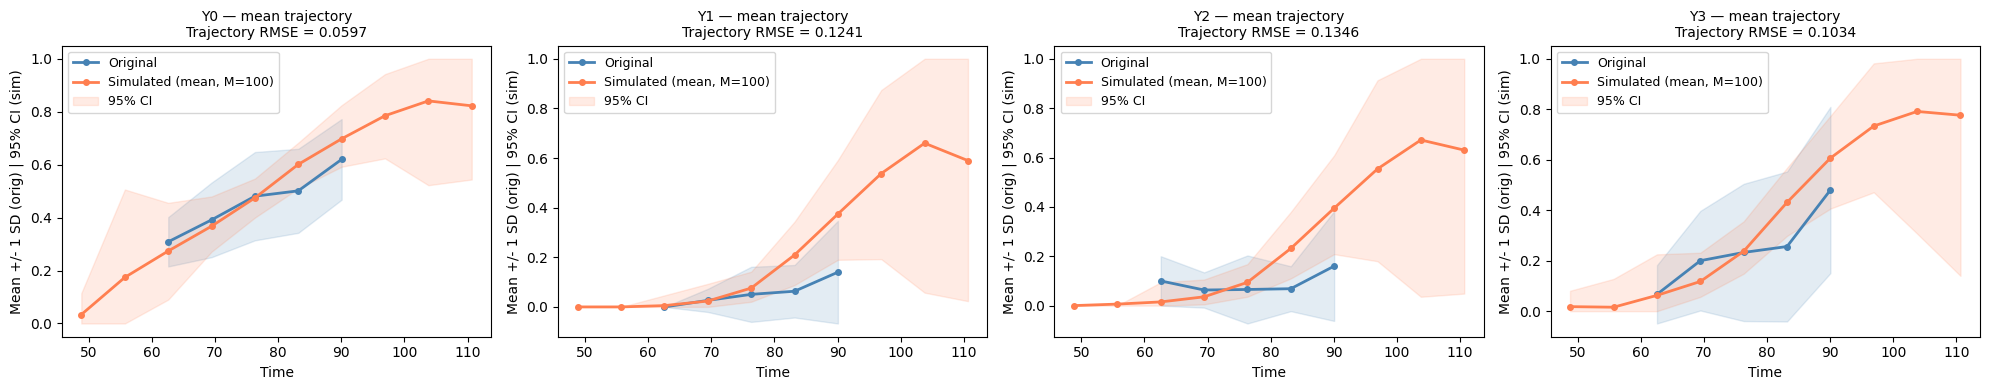

Trajectory RMSE per outcome: {'Y0': 0.0597, 'Y1': 0.1241, 'Y2': 0.1346, 'Y3': 0.1034}


In [7]:
def trajectory_comparison_avg(df, sims, outcome_cols, n_bins=10):
    all_times    = pd.concat([df['TIME']] + [s['TIME'] for s in sims])
    all_bin_cats = pd.cut(all_times, bins=n_bins).cat.categories
    bin_centers  = np.array([iv.mid for iv in all_bin_cats])

    fig, axes = plt.subplots(1, len(outcome_cols), figsize=(5 * len(outcome_cols), 4))
    if len(outcome_cols) == 1:
        axes = [axes]

    traj_metrics = {}
    for ax, col in zip(axes, outcome_cols):
        # Original bin means
        df2 = df.copy()
        df2['_bin'] = pd.cut(df2['TIME'], bins=all_bin_cats)
        m_orig  = df2.groupby('_bin', observed=False)[col].mean().reindex(all_bin_cats).values
        sd_orig = df2.groupby('_bin', observed=False)[col].std().reindex(all_bin_cats).values

        ax.plot(bin_centers, m_orig, marker='o', ms=4, lw=2, label='Original', color='steelblue')
        ax.fill_between(bin_centers,
                        np.where(np.isnan(m_orig - sd_orig), np.nan, m_orig - sd_orig),
                        np.where(np.isnan(m_orig + sd_orig), np.nan, m_orig + sd_orig),
                        alpha=0.15, color='steelblue')

        # Per-simulation bin means -> 95% CI across M sims
        sim_means = []
        for df_s in sims:
            ds2 = df_s.copy()
            ds2['_bin'] = pd.cut(ds2['TIME'], bins=all_bin_cats)
            m_s = ds2.groupby('_bin', observed=False)[col].mean().reindex(all_bin_cats).values
            sim_means.append(m_s)
        sim_means  = np.array(sim_means)
        m_sim_avg  = np.nanmean(sim_means, axis=0)
        m_sim_lo   = np.nanpercentile(sim_means, 2.5, axis=0)
        m_sim_hi   = np.nanpercentile(sim_means, 97.5, axis=0)

        ax.plot(bin_centers, m_sim_avg, marker='o', ms=4, lw=2,
                label=f'Simulated (mean, M={len(sims)})', color='coral')
        ax.fill_between(bin_centers,
                        np.where(np.isnan(m_sim_lo), np.nan, m_sim_lo),
                        np.where(np.isnan(m_sim_hi), np.nan, m_sim_hi),
                        alpha=0.15, color='coral', label='95% CI')

        rmse = np.sqrt(np.nanmean((m_orig - m_sim_avg) ** 2))
        traj_metrics[col] = round(rmse, 4)

        ax.set_title(f'{col} — mean trajectory\nTrajectory RMSE = {rmse:.4f}', fontsize=10)
        ax.set_xlabel('Time')
        ax.set_ylabel('Mean +/- 1 SD (orig) | 95% CI (sim)')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    return traj_metrics

traj = trajectory_comparison_avg(df, sims, model.features)
print('Trajectory RMSE per outcome:', traj)


### Kaplan-Meier

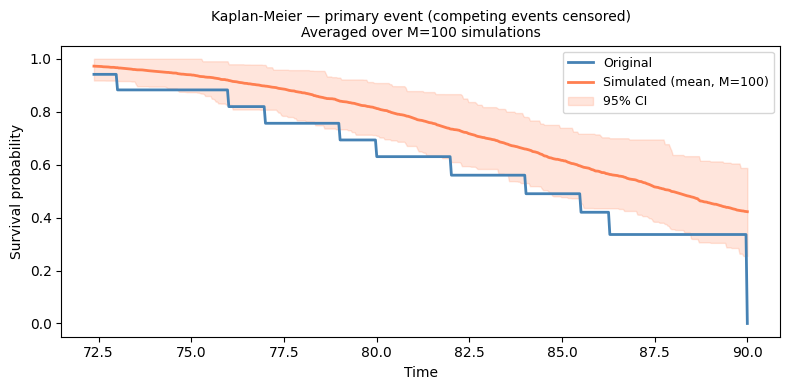

Integrated |KM difference|: 2.1377

Event-type rates (original):
  censored: 0.353
  primary event: 0.647

Event-type rates (simulated, mean +/- std over M=100):
  censored: 0.504 +/- 0.073
  primary event: 0.496 +/- 0.073
  competing event: 0.000 +/- 0.000


In [8]:
# One row per patient — original
# EVENT_BOOL: 0 = censored, 1 = primary event, 2 = competing event
# KM treats competing events as censored (standard, if biased, approach)
surv_orig = (
    df.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']]
    .dropna()
    .copy()
)
surv_orig['event'] = (surv_orig['EVENT_BOOL'] == 1).astype(int)

# Common time grid (derived from original cohort range only)
t_min = surv_orig['EVENT_TIME'].min()
t_max = surv_orig['EVENT_TIME'].max()
t_grid = np.linspace(t_min, t_max, 500)

# KM for original
kmf_orig = KaplanMeierFitter()
kmf_orig.fit(surv_orig['EVENT_TIME'], event_observed=surv_orig['event'])
s_orig = kmf_orig.survival_function_at_times(t_grid).values

# KM for each simulation -> collect survival curves on the common grid
s_sims = []
event_rates = {k: [] for k in [0, 1, 2]}

for df_s in sims:
    surv_s = (
        df_s.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']]
        .dropna()
        .copy()
    )
    surv_s['event'] = (surv_s['EVENT_BOOL'] == 1).astype(int)
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(surv_s['EVENT_TIME'], event_observed=surv_s['event'])
    s_sims.append(kmf_s.survival_function_at_times(t_grid).values)
    vc = surv_s['EVENT_BOOL'].value_counts(normalize=True)
    for k in [0, 1, 2]:
        event_rates[k].append(vc.get(k, 0.0))

s_sims     = np.array(s_sims)          # (M, 500)
s_sim_mean = s_sims.mean(axis=0)
s_sim_lo   = np.percentile(s_sims, 2.5, axis=0)
s_sim_hi   = np.percentile(s_sims, 97.5, axis=0)

integrated_diff = np.trapz(np.abs(s_orig - s_sim_mean), t_grid)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_grid, s_orig, color='steelblue', lw=2, label='Original')
ax.plot(t_grid, s_sim_mean, color='coral', lw=2, label=f'Simulated (mean, M={M})')
ax.fill_between(t_grid, s_sim_lo, s_sim_hi,
                alpha=0.2, color='coral', label='95% CI')
ax.set_title(
    f'Kaplan-Meier — primary event (competing events censored)\n'
    f'Averaged over M={M} simulations',
    fontsize=10
)
ax.set_xlabel('Time')
ax.set_ylabel('Survival probability')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Integrated |KM difference|:', round(integrated_diff, 4))

# Event-type breakdown
names = {0: 'censored', 1: 'primary event', 2: 'competing event'}
vc_orig = surv_orig['EVENT_BOOL'].value_counts(normalize=True).sort_index()
print('\nEvent-type rates (original):')
for k, v in vc_orig.items():
    print(f"  {names.get(k, k)}: {v:.3f}")
print(f'\nEvent-type rates (simulated, mean +/- std over M={M}):')
for k in [0, 1, 2]:
    vals = event_rates[k]
    print(f"  {names[k]}: {np.mean(vals):.3f} +/- {np.std(vals):.3f}")


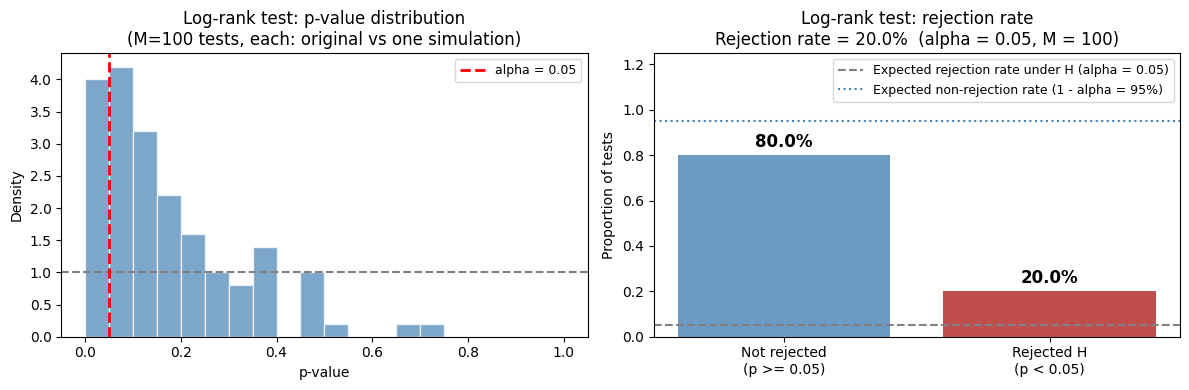

Log-rank test summary (original vs each simulation, alpha = 0.05, M = 100):
  Rejected H (p < alpha) : 20 / 100  (20.0%)
  Median p-value      : 0.1292
  Mean p-value        : 0.1744


In [9]:

from lifelines.statistics import logrank_test

alpha = 0.05
pvalues = []

for df_s in sims:
    surv_s = (
        df_s.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']]
        .dropna()
        .copy()
    )
    surv_s['event'] = (surv_s['EVENT_BOOL'] == 1).astype(int)
    result = logrank_test(
        surv_orig['EVENT_TIME'], surv_s['EVENT_TIME'],
        event_observed_A=surv_orig['event'],
        event_observed_B=surv_s['event'],
    )
    pvalues.append(result.p_value)

pvalues       = np.array(pvalues)
rejection_rate = (pvalues < alpha).mean()
n_rejected     = (pvalues < alpha).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pvalues, bins=20, range=(0, 1),
             color='steelblue', alpha=0.7, edgecolor='white', density=True)
axes[0].axhline(1.0, color='gray', lw=1.5, linestyle='--')
axes[0].axvline(alpha, color='red', lw=2, linestyle='--', label=f'alpha = {alpha}')
axes[0].set_xlabel('p-value')
axes[0].set_ylabel('Density')
axes[0].set_title(
    f'Log-rank test: p-value distribution\n'
    f'(M={M} tests, each: original vs one simulation)'
)
axes[0].legend(fontsize=9)

bars = axes[1].bar(
    [f'Not rejected\n(p >= {alpha})', f'Rejected H\n(p < {alpha})'],
    [1 - rejection_rate, rejection_rate],
    color=['steelblue', 'firebrick'], alpha=0.8,
)
for bar, v in zip(bars, [1 - rejection_rate, rejection_rate]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                 f'{v:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].axhline(alpha, color='gray', lw=1.5, linestyle='--',
                label=f'Expected rejection rate under H (alpha = {alpha})')
axes[1].axhline(1 - alpha, color='steelblue', lw=1.5, linestyle=':',
                label=f'Expected non-rejection rate (1 - alpha = {1-alpha:.0%})')
axes[1].set_ylabel('Proportion of tests')
axes[1].set_ylim(0, 1.25)
axes[1].set_title(
    f'Log-rank test: rejection rate\n'
    f'Rejection rate = {rejection_rate:.1%}  (alpha = {alpha}, M = {M})'
)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Log-rank test summary (original vs each simulation, alpha = {alpha}, M = {M}):')
print(f'  Rejected H (p < alpha) : {n_rejected} / {M}  ({rejection_rate:.1%})')
print(f'  Median p-value      : {np.median(pvalues):.4f}')
print(f'  Mean p-value        : {np.mean(pvalues):.4f}')

### Histograms for time

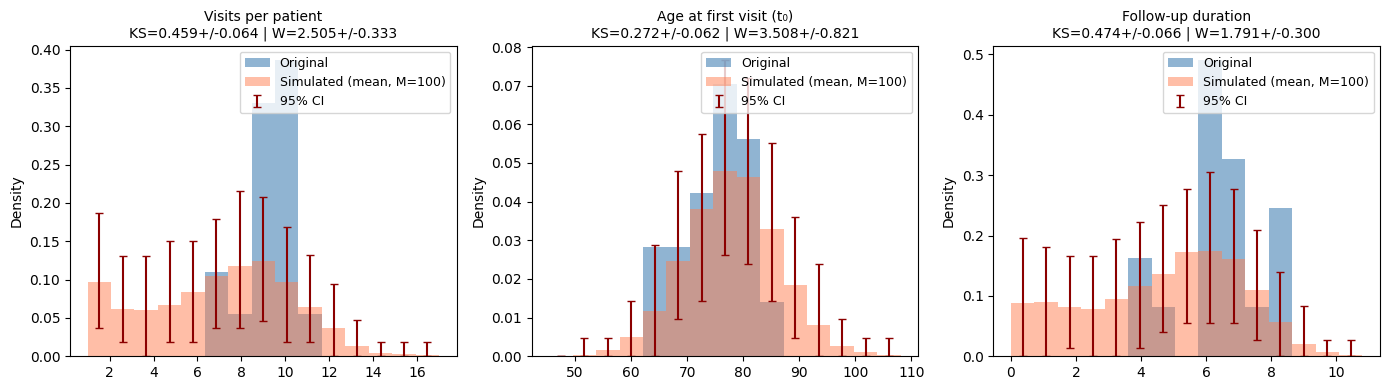

,Metric,Mean (orig),Mean (sim avg),SD (orig),SD (sim avg)
0,n_visits,9.235,7.094,1.059,3.097
1,age_first_visit,75.064,77.964,5.578,8.103
2,followup_duration,6.419,4.697,1.168,2.326


In [10]:
def visit_process_metrics_avg(df, sims):
    n_orig  = df.groupby('ID').size().values
    t0_orig = df.groupby('ID')['TIME'].min().values
    fu_orig = df.groupby('ID')['TIME'].apply(lambda x: x.max() - x.min()).values

    n_per, t0_per, fu_per = [], [], []
    for df_s in sims:
        n_per.append(df_s.groupby('ID').size().values)
        t0_per.append(df_s.groupby('ID')['TIME'].min().values)
        fu_per.append(df_s.groupby('ID')['TIME'].apply(lambda x: x.max() - x.min()).values)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    metrics = {}

    for ax, (a, b_list, title) in zip(axes, [
        (n_orig,  n_per,  'Visits per patient'),
        (t0_orig, t0_per, 'Age at first visit (t₀)'),
        (fu_orig, fu_per, 'Follow-up duration'),
    ]):
        all_vals  = np.concatenate([a] + b_list)
        bin_edges = np.linspace(all_vals.min(), all_vals.max(), 16)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        counts, _ = np.histogram(a, bins=bin_edges, density=True)
        ax.bar(bin_centers, counts, width=np.diff(bin_edges),
               alpha=0.6, label='Original', color='steelblue')

        all_densities = np.array([
            np.histogram(b, bins=bin_edges, density=True)[0] for b in b_list
        ])
        mean_d = all_densities.mean(axis=0)
        lo_d   = np.maximum(np.percentile(all_densities, 2.5, axis=0), 0)
        hi_d   = np.percentile(all_densities, 97.5, axis=0)
        ax.bar(bin_centers, mean_d, width=np.diff(bin_edges),
               alpha=0.5, label=f'Simulated (mean, M={len(sims)})', color='coral')
        ax.errorbar(bin_centers, mean_d,
                    yerr=[np.maximum(mean_d - lo_d, 0), np.maximum(hi_d - mean_d, 0)],
                    fmt='none', color='darkred', capsize=3, label='95% CI')

        ks_vals   = [ks_2samp(a, b)[0]         for b in b_list]
        wass_vals = [wasserstein_distance(a, b) for b in b_list]
        ks_m,   ks_s   = np.mean(ks_vals),   np.std(ks_vals)
        wass_m, wass_s = np.mean(wass_vals), np.std(wass_vals)

        ax.set_title(f'{title}\nKS={ks_m:.3f}+/-{ks_s:.3f} | W={wass_m:.3f}+/-{wass_s:.3f}', fontsize=10)
        ax.legend(fontsize=9)
        ax.set_ylabel('Density')
        ax.set_ylim(bottom=0)
        metrics[title] = {
            'KS_mean': round(ks_m, 4),   'KS_std': round(ks_s, 4),
            'W_mean':  round(wass_m, 4), 'W_std':  round(wass_s, 4),
        }

    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame({
        'Metric':         ['n_visits', 'age_first_visit', 'followup_duration'],
        'Mean (orig)':    [n_orig.mean(),  t0_orig.mean(),  fu_orig.mean()],
        'Mean (sim avg)': [np.mean([b.mean() for b in n_per]),
                           np.mean([b.mean() for b in t0_per]),
                           np.mean([b.mean() for b in fu_per])],
        'SD (orig)':      [n_orig.std(),   t0_orig.std(),   fu_orig.std()],
        'SD (sim avg)':   [np.mean([b.std() for b in n_per]),
                           np.mean([b.std() for b in t0_per]),
                           np.mean([b.std() for b in fu_per])],
    }).round(3)
    return metrics, summary

visit_metrics, visit_summary = visit_process_metrics_avg(df, sims)
display(visit_summary)


Original data:
  Patients with exactly 1 visit : 0 / 17 (0.0%)

Simulations (M=100):
  Patients with exactly 1 visit : 1.9 / 50 (3.9%) — 95% CI [0.0, 5.0]


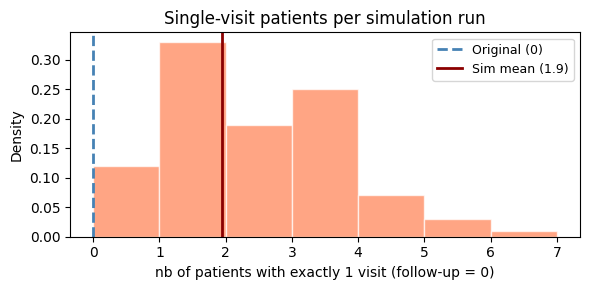

In [11]:
# Diagnosis: patients with a single visit (follow-up == 0) 

# Original data
n_visits_orig = df.groupby('ID').size()
single_visit_orig = (n_visits_orig == 1).sum()
total_orig = len(n_visits_orig)

print("Original data:")
print(f"  Patients with exactly 1 visit : {single_visit_orig} / {total_orig}"
      f" ({100 * single_visit_orig / total_orig:.1f}%)")

# Simulations: distribution of the single-visit count across M runs
single_visit_counts = []
for df_s in sims:
    nv = df_s.groupby('ID').size()
    single_visit_counts.append((nv == 1).sum())

sv_arr = np.array(single_visit_counts)
sv_lo  = np.percentile(sv_arr, 2.5)
sv_hi  = np.percentile(sv_arr, 97.5)

print(f"\nSimulations (M={M}):")
print(f"  Patients with exactly 1 visit : {sv_arr.mean():.1f} / 50"
      f" ({100 * sv_arr.mean() / 50:.1f}%) — 95% CI [{sv_lo:.1f}, {sv_hi:.1f}]")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(sv_arr, bins=range(int(sv_arr.min()), int(sv_arr.max()) + 2),
        density=True, color='coral', alpha=0.7, edgecolor='white')
ax.axvline(single_visit_orig, color='steelblue', lw=2, linestyle='--',
           label=f'Original ({single_visit_orig})')
ax.axvline(sv_arr.mean(), color='darkred', lw=2, linestyle='-',
           label=f'Sim mean ({sv_arr.mean():.1f})')
ax.set_xlabel('nb of patients with exactly 1 visit (follow-up = 0)')
ax.set_ylabel('Density')
ax.set_title('Single-visit patients per simulation run')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Feature Correlation Structure

Max Absolute Correlation difference (M=100 avg): 0.2221
Mean Absolute Correlation difference (M=100 avg): 0.1420


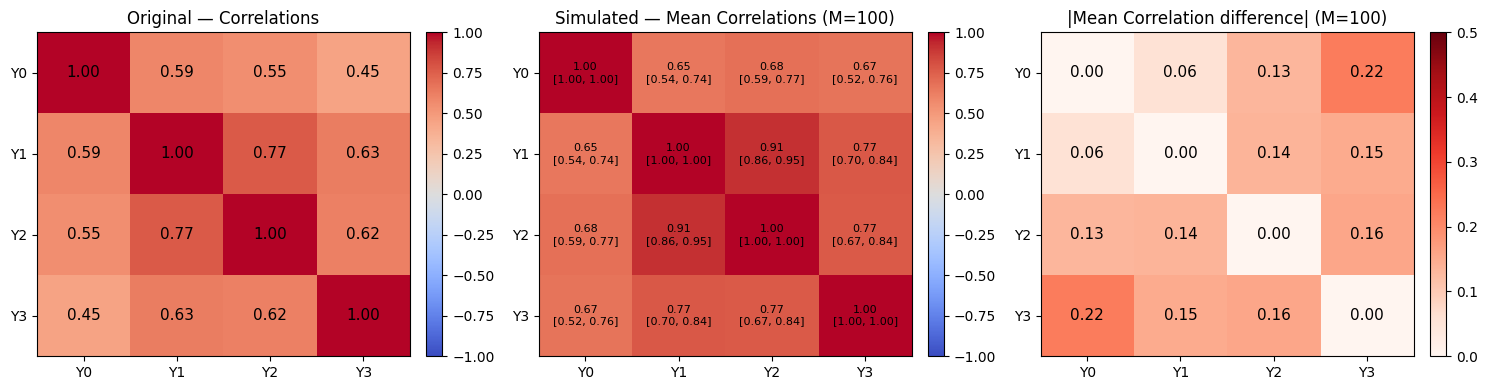

In [12]:
corr_orig = df[feat_cols].corr()

# Per-simulation correlation matrices -> mean and 95% CI
corr_mats     = np.array([s[feat_cols].corr().values for s in sims])   # (M, 4, 4)
corr_sim_mean = corr_mats.mean(axis=0)
corr_sim_lo   = np.percentile(corr_mats, 2.5, axis=0)
corr_sim_hi   = np.percentile(corr_mats, 97.5, axis=0)
corr_diff_mean = np.abs(corr_orig.values - corr_sim_mean)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, corr, title, cmap, vmin, vmax in [
    (axes[0], corr_orig.values, 'Original — Correlations',                    'coolwarm', -1, 1),
    (axes[1], corr_sim_mean,    f'Simulated — Mean Correlations (M={M})',      'coolwarm', -1, 1),
    (axes[2], corr_diff_mean,   f'|Mean Correlation difference| (M={M})',      'Reds',      0, 0.5),
]:
    im = ax.imshow(corr, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(feat_cols))); ax.set_xticklabels(feat_cols)
    ax.set_yticks(range(len(feat_cols))); ax.set_yticklabels(feat_cols)
    for i in range(len(feat_cols)):
        for j in range(len(feat_cols)):
            val = corr[i, j]
            if ax is axes[1]:
                ax.text(j, i, f'{val:.2f}\n[{corr_sim_lo[i,j]:.2f}, {corr_sim_hi[i,j]:.2f}]',
                        ha='center', va='center', fontsize=8)
            else:
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

upper = np.triu_indices(len(feat_cols), k=1)
print(f'Max Absolute Correlation difference (M={M} avg): {corr_diff_mean[upper].max():.4f}')
print(f'Mean Absolute Correlation difference (M={M} avg): {corr_diff_mean[upper].mean():.4f}')

plt.tight_layout()
plt.show()


## Cumulative Incidence Functions (for competing events)

With competing events, the Kaplan-Meier estimator is biased; the proper tool is the **Aalen-Johansen** estimator, which gives the cumulative incidence function (CIF) for each cause.

In [13]:

# from lifelines import AalenJohansenFitter

# # Common time grid (from original)
# t_grid_cif = np.linspace(surv_orig['EVENT_TIME'].min(), surv_orig['EVENT_TIME'].max(), 200)

# def get_cif_values(surv_df, event_of_interest, t_grid):
#     ajf = AalenJohansenFitter(calculate_variance=False)
#     ajf.fit(surv_df['EVENT_TIME'], surv_df['EVENT_BOOL'], event_of_interest=event_of_interest)
#     return ajf.cumulative_density_at_times(t_grid).values

# # CIFs for the original
# cif1_orig = get_cif_values(surv_orig, 1, t_grid_cif)
# cif2_orig = get_cif_values(surv_orig, 2, t_grid_cif)

# # CIFs for each simulation
# cif1_sims, cif2_sims = [], []
# for df_s in sims:
#     surv_s = df_s.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']].dropna()
#     cif1_sims.append(get_cif_values(surv_s, 1, t_grid_cif))
#     cif2_sims.append(get_cif_values(surv_s, 2, t_grid_cif))

# cif1_sims = np.array(cif1_sims)   # (M, 200)
# cif2_sims = np.array(cif2_sims)

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# for ax, cif_orig, cif_arr, label in [
#     (axes[0], cif1_orig, cif1_sims, 'Primary event'),
#     (axes[1], cif2_orig, cif2_sims, 'Competing event'),
# ]:
#     cif_mean = cif_arr.mean(axis=0)
#     cif_std  = cif_arr.std(axis=0)

#     ax.plot(t_grid_cif, cif_orig, color='steelblue', lw=2, label='Original')
#     ax.plot(t_grid_cif, cif_mean, color='coral',     lw=2, label=f'Simulated (mean, M={M})')
#     ax.fill_between(t_grid_cif, cif_mean - cif_std, cif_mean + cif_std,
#                     alpha=0.2, color='coral', label='+/-1 SD')

#     diff = np.trapz(np.abs(cif_orig - cif_mean), t_grid_cif)
#     ax.set_title(f'CIF — {label}\nIntegrated |diff| = {diff:.4f}')
#     ax.set_xlabel('Time')
#     ax.set_ylabel('Cumulative Incidence')
#     ax.legend(fontsize=9)

# plt.tight_layout()
# plt.show()
